<a href="https://colab.research.google.com/github/priscilla1812/Pharmacy-Drug-Side-Effect-ML-Project/blob/main/Priscilla_541_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MAI412-1–MACHINE LEARNING

Priscilla Philby Oommen -- Reg No. 2648541 -- MSc AI & ML

Regular lab Question – II

# Lab Exercise  2: Preprocessing the Dataset Using Normalization Techniques


**Objective**:
 To apply appropriate normalization techniques on a dataset from a specific domain and analyze the impact of normalization on the feature values.

**Problem Statement**
Select a dataset from your chosen domain (Healthcare, Education, Finance, Agriculture, Retail, Sports, etc.) and perform preprocessing by applying suitable normalization techniques to the numerical attributes.


## Part A: Dataset Understanding

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import warnings
warnings.filterwarnings('ignore')

1. Identify the domain of the dataset.

The domain of the data set is Pharmacy domain. The name of the dataset is 100k Drug Side Effects Dataset. It is from Kaggle website.

In [ ]:
# Upload CSV or connect to Kaggle dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv('/content/drive/My Drive/Colab Notebooks/drug_side_effects_100k_dataset.csv')
df = pd.DataFrame(data)

In [ ]:
df.head()

,patient_id,age,gender,country,drug_name,dosage_mg,side_effect,severity,outcome,report_date,treatment_start_date,chronic_condition,smoker,alcohol_use,hospitalized,recovery_days
0,PT-100000,56,Female,USA,Atorvastatin,25,Muscle Pain,Moderate,Recovering,2021-12-08,2021-11-23,Hypertension,Yes,Frequent,No,36.0
1,PT-100001,45,Male,USA,Sertraline,5,Dry Mouth,Mild,Recovered,2023-02-10,2023-02-04,Hypertension,Yes,Frequent,No,40.0
2,PT-100002,76,Female,Pakistan,Insulin,25,Hypoglycemia,Mild,Recovering,2021-07-30,2021-07-01,Heart Disease,No,NaN,No,12.0
3,PT-100003,61,Female,USA,Paracetamol,20,Rash,Moderate,Recovered,2025-05-02,2025-04-18,Asthma,Yes,NaN,No,26.0
4,PT-100004,39,Female,India,Amlodipine,5,Dizziness,Mild,Recovered,2025-05-23,2025-04-06,NaN,Yes,Occasional,No,7.0


2. List all numerical and categorical attributes.

In [ ]:
numerical_attributes = df.select_dtypes(include=['number']).columns.tolist()
categorical_attributes = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Attributes:", numerical_attributes)
print("Categorical Attributes:", categorical_attributes)

Numerical Attributes: ['age', 'dosage_mg', 'recovery_days']
Categorical Attributes: ['patient_id', 'gender', 'country', 'drug_name', 'side_effect', 'severity', 'outcome', 'report_date', 'treatment_start_date', 'chronic_condition', 'smoker', 'alcohol_use', 'hospitalized']


In [ ]:
print("Dataset features and their data types:")
df.info()

Dataset features and their data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   patient_id            100000 non-null  object 
 1   age                   100000 non-null  int64  
 2   gender                100000 non-null  object 
 3   country               100000 non-null  object 
 4   drug_name             100000 non-null  object 
 5   dosage_mg             100000 non-null  int64  
 6   side_effect           100000 non-null  object 
 7   severity              100000 non-null  object 
 8   outcome               100000 non-null  object 
 9   report_date           100000 non-null  object 
 10  treatment_start_date  100000 non-null  object 
 11  chronic_condition     83257 non-null   object 
 12  smoker                100000 non-null  object 
 13  alcohol_use           66635 non-null   object 
 14  hospitalized  

In [ ]:
df.describe()

,age,dosage_mg,recovery_days
count,100000.000000,100000.000000,88262.000000
mean,47.781740,119.896250,23.569996
std,17.055106,162.249791,12.690178
min,18.000000,5.000000,2.000000
25%,35.000000,10.000000,13.000000
50%,47.000000,25.000000,24.000000
75%,60.000000,250.000000,35.000000
max,90.000000,500.000000,45.000000


- The age of patients is in the range 18-90. min.age is 18 and max. age is 90. the average age is 47.
- The min. medicine dosage is 5mg and max. dosage is 500mg

3. Explain why normalization is required for the selected dataset.

**Scale Disparities:** The numerical metrics exist on completely different scales. 'age' ranges from 1 to 95 years, 'recovery_days' spans 1 to 30 days, while 'dosage_mg' features significantly larger values (up to 500 mg).

If left unscaled, the model will treat dosage_mg as the dominant feature simply due to its higher numerical magnitude, completely masking critical subtle variations in recovery_days or age.

In [ ]:
df['severity'].value_counts()

,count
severity,
Mild,61969
Moderate,29926
Severe,8105


<Axes: xlabel='severity', ylabel='count'>

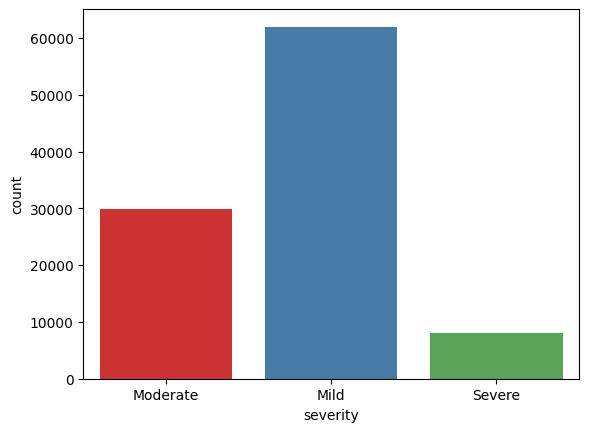

In [ ]:
sns.countplot(data=df,x=df['severity'],palette = 'Set1')

Description of Dataset Features:

1. patient_id =	Unique patient identifier
2. age	= age of Patient
3. gender =	Male / Female / Other
4. country	= Patient's country of origin/residence
5. drug_name	= Prescribed medication
6. dosage_mg	= Drug dosage in mg
7. side_effect	= Reported adverse reaction
8. severity = Mild / Moderate / Severe
9. outcome	= Recovery status
10. report_date	= Side effect report date
11. treatment_start_date = Medication start date
12. chronic_condition	= Existing health condition
13. smoker	= Smoking status
14. alcohol_use	= Alcohol consumption pattern
15. hospitalized	= Hospitalization status
16. recovery_days	= Recovery duration

## Part B: Data Preparation

1. Load and inspect the dataset.

2. Handle missing values (if any).

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
patient_id                  0
age                         0
gender                      0
country                     0
drug_name                   0
dosage_mg                   0
side_effect                 0
severity                    0
outcome                     0
report_date                 0
treatment_start_date        0
chronic_condition       16743
smoker                      0
alcohol_use             33365
hospitalized                0
recovery_days           11738
dtype: int64


there are missing values in the columns of the dataset such as chronic_condition, alcohol_use, and recovery_days

In [ ]:
# Impute 'recovery_days' column with its mode
df['recovery_days'].fillna(df['recovery_days'].mode()[0], inplace=True)

3. Remove duplicate records (if any).

In [ ]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

there are no duplicated records

In [ ]:
invalid_age = df[df['age'] < 0].shape[0]
invalid_dates = df[df['report_date'] < df['treatment_start_date']].shape[0]
unknown_gender = df[df['gender'] == 'Unknown'].shape[0]

print(f"Rows with negative age: {invalid_age}")
print(f"Rows where report_date is before treatment_start_date: {invalid_dates}")
print(f"Rows with 'Unknown' gender placeholder: {unknown_gender}\n")

Rows with negative age: 0
Rows where report_date is before treatment_start_date: 0
Rows with 'Unknown' gender placeholder: 0



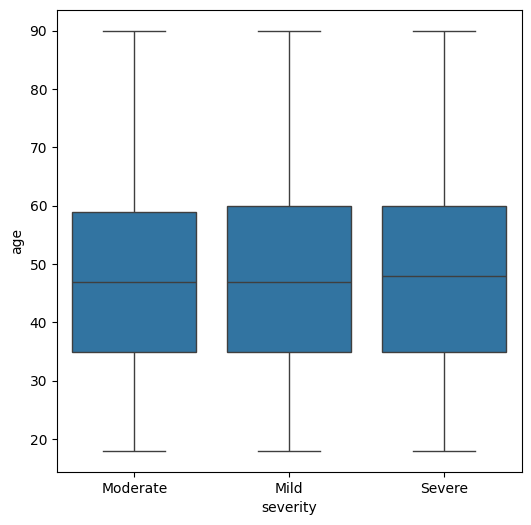

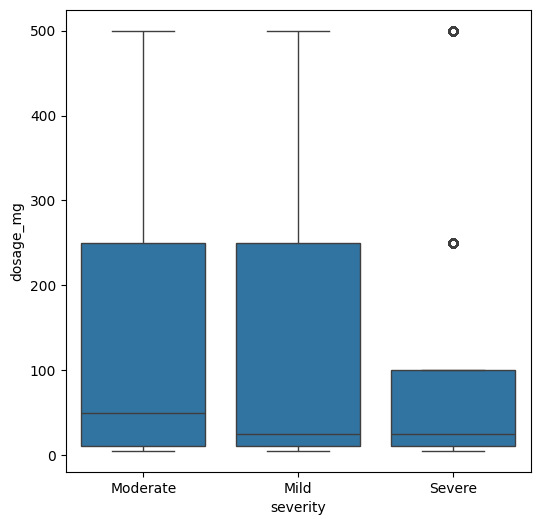

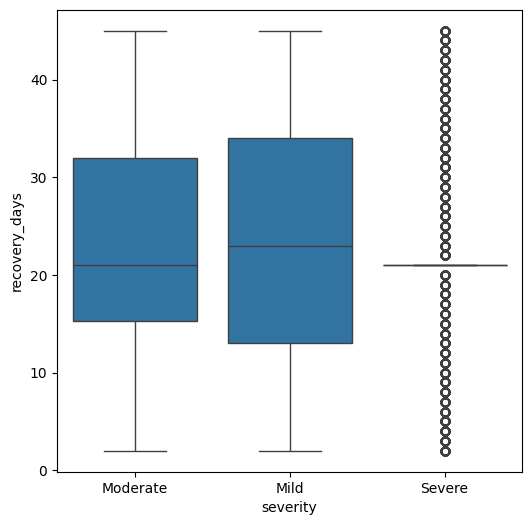

In [ ]:
# Boxplot
numerical_features = ['age', 'dosage_mg', 'recovery_days']

severity = ['Mild', 'Moderate','Severe']

for feature in numerical_features:
    plt.figure(figsize=(6, 6))
    sns.boxplot(x='severity', y=feature, data=df[df['severity'].isin(severity)])

the feature 'recovery_days' contains many outliers

In [ ]:
completeness = (1 - (df.isnull().sum().sum() / df.size)) * 100
print(f"Overall Data Completeness Score: {completeness:.2f}%")
print("Reliability Concerns: Outliers in 'recovery_days'")

Overall Data Completeness Score: 96.87%
Reliability Concerns: Outliers in 'recovery_days'


In [ ]:
# Correct recovery days outlier placeholder
median_rec = df.loc[df['recovery_days'] != 999, 'recovery_days'].median()
df['recovery_days'] = df['recovery_days'].replace(999, median_rec)

# Handling Missing values in chronic_condition, alcohol_use
df['chronic_condition'].fillna('Unknown', inplace=True)
df['alcohol_use'].fillna('Unknown', inplace=True)

print(f"Data cleaned.")

Data cleaned.


4. Add Proper visualization before and after normalization (Bar graph, Box Plot, Line graph …..)

In [ ]:
# Isolate target continuous features for transformation comparison
features_to_scale = ['age', 'dosage_mg', 'recovery_days']
df_original = df[features_to_scale].copy()

Part C: Normalization Techniques

Apply the following normalization methods to suitable numerical attributes:
1. Min-Max Normalization
- Scale the values between 0 and 1.
- Compare original and normalized values.
2. Z-Score Normalization (Standardization)
- Transform data to have mean = 0 and standard deviation = 1.
- Analyze the resulting distribution.

In [ ]:
# 1. Min-Max Normalization (Scale strictly between [0, 1])
min_max_scaler = MinMaxScaler(feature_range=(0, 1))
df_minmax = pd.DataFrame(
    min_max_scaler.fit_transform(df_original),
    columns=[f"{col}_minmax" for col in features_to_scale],
    index=df.index
)

In [ ]:
# 2. Z-Score Normalization (Standardization: Mean=0, Std=1)
z_scaler = StandardScaler()
df_zscore = pd.DataFrame(
    z_scaler.fit_transform(df_original),
    columns=[f"{col}_zscore" for col in features_to_scale],
    index=df.index
)

In [ ]:
# Merge back into a master comparison matrix
df_comparison = pd.concat([df_original, df_minmax, df_zscore], axis=1)
print("Transformation matrices computed. Sample verification comparisons:")
print(df_comparison[['age', 'age_minmax', 'age_zscore']].head(3))

Transformation matrices computed. Sample verification comparisons:
   age  age_minmax  age_zscore
0   56    0.527778    0.481867
1   45    0.375000   -0.163104
2   76    0.805556    1.654543


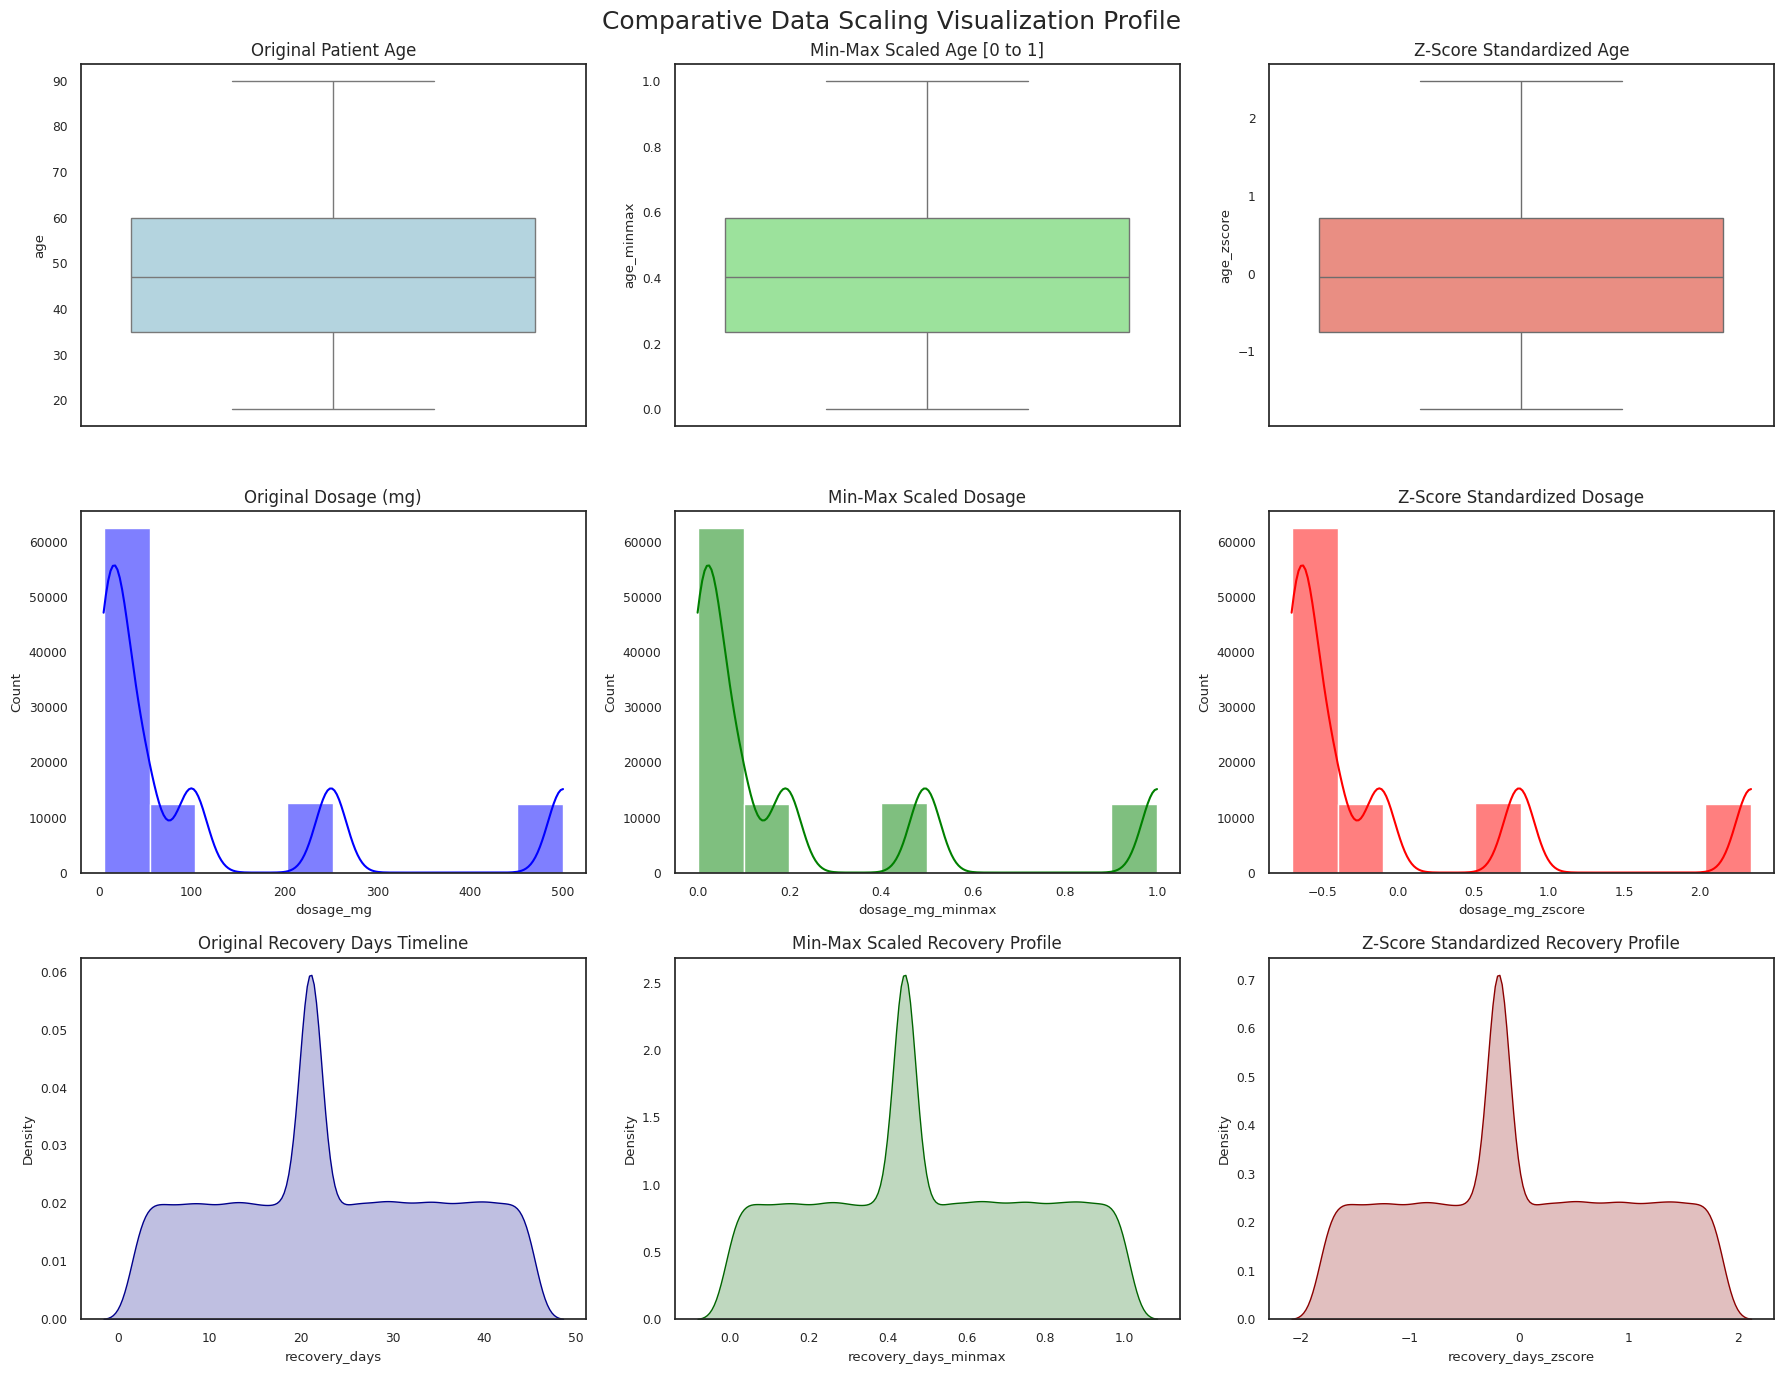

In [ ]:
# Setup layout for comparative visual analysis
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
sns.set_theme(style="whitegrid")

# Column 1: Original Distribution Layouts
sns.boxplot(data=df_comparison, y='age', ax=axes[0,0], color='lightblue')
axes[0,0].set_title("Original Patient Age")
sns.histplot(data=df_comparison, x='dosage_mg', bins=10, ax=axes[1,0], color='blue', kde=True)
axes[1,0].set_title("Original Dosage (mg)")
sns.kdeplot(data=df_comparison, x='recovery_days', ax=axes[2,0], color='darkblue', fill=True)
axes[2,0].set_title("Original Recovery Days Timeline")

# Column 2: Min-Max Transformed Results [0, 1]
sns.boxplot(data=df_comparison, y='age_minmax', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title("Min-Max Scaled Age [0 to 1]")
sns.histplot(data=df_comparison, x='dosage_mg_minmax', bins=10, ax=axes[1,1], color='green', kde=True)
axes[1,1].set_title("Min-Max Scaled Dosage")
sns.kdeplot(data=df_comparison, x='recovery_days_minmax', ax=axes[2,1], color='darkgreen', fill=True)
axes[2,1].set_title("Min-Max Scaled Recovery Profile")

# Column 3: Z-Score Standardized Results (Mean=0, Std=1)
sns.boxplot(data=df_comparison, y='age_zscore', ax=axes[0,2], color='salmon')
axes[0,2].set_title("Z-Score Standardized Age")
sns.histplot(data=df_comparison, x='dosage_mg_zscore', bins=10, ax=axes[1,2], color='red', kde=True)
axes[1,2].set_title("Z-Score Standardized Dosage")
sns.kdeplot(data=df_comparison, x='recovery_days_zscore', ax=axes[2,2], color='darkred', fill=True)
axes[2,2].set_title("Z-Score Standardized Recovery Profile")

plt.suptitle("Comparative Data Scaling Visualization Profile", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

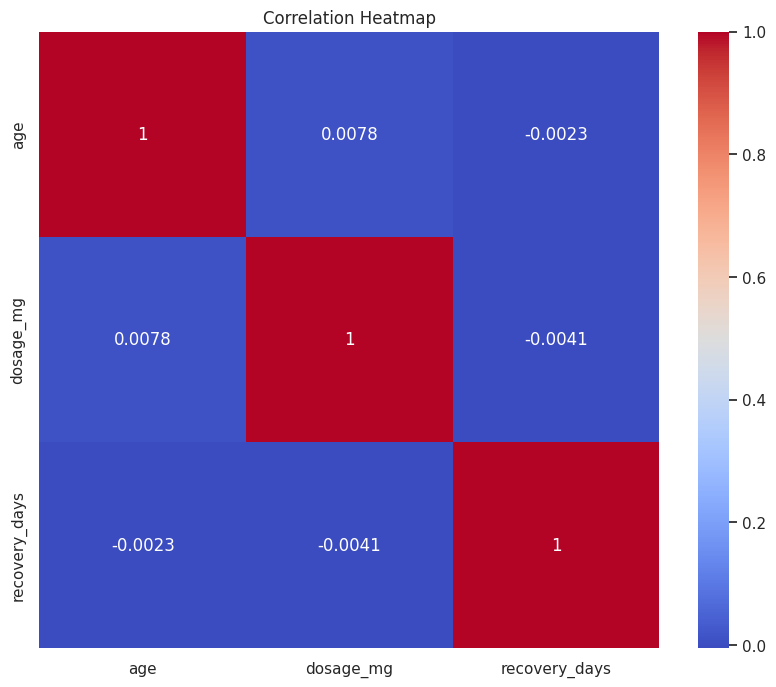

In [ ]:
# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

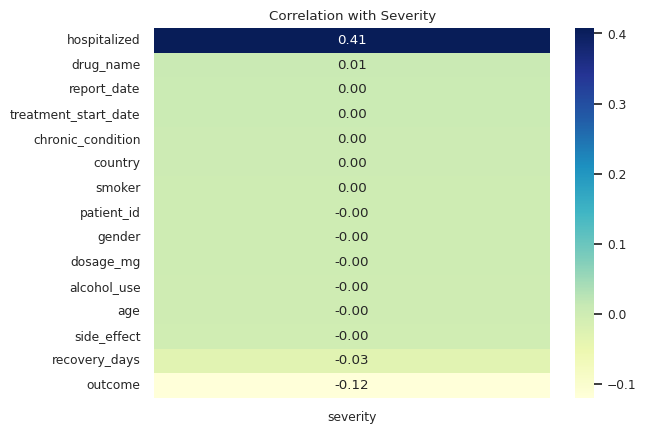

In [ ]:
# Encode 'severity' to numerical for correlation calculation
# The df_temp_corr is not needed if we are going to use df_encoded for correlations
le = LabelEncoder()

# Label Encoding all categorical features (including 'severity')
df_encoded = df.copy()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

# Calculate correlations on df_encoded which now contains all numerical features
# (original numerical + label-encoded categorical, including 'severity')
correlations = df_encoded.corr(numeric_only=True) # Keep numeric_only=True just in case there are other non-numeric columns we don't want to correlate

# Extract correlations with the 'severity' column (which is now numerical in df_encoded)
# And drop 'severity' itself from the list of correlations
target_corr = correlations['severity'].drop('severity')
target_corr_sorted = target_corr.sort_values(ascending=False)

sns.set(font_scale=0.8)
sns.set_style("white")
sns.set_palette("PuBuGn_d")
sns.heatmap(target_corr_sorted.to_frame(), cmap="YlGnBu", annot=True, fmt='.2f')
plt.title('Correlation with Severity')
plt.show()

the feature 'hospitalized' is strongly correlated with 'Severity' target feature

- 'drug_name' & 'dosage_mg': High relevance. Directly dictates pharmacological impact.
- 'smoker' & 'alcohol_use': High relevance. Crucial metabolic lifestyle confounders.
- 'country': Low biological relevance, high regulatory/reporting pipeline relevance.

- 'patient_id': High cardinality identifier; unique for every row, contains zero predictive entropy.
- If 'hospitalized' directly correlates 100% with 'severity=Severe', one could become redundant.

* Numerical (Continuous/Discrete): 'age', 'dosage_mg', 'recovery_days'
 * Categorical (Nominal): 'patient_id', 'country', 'drug_name', 'side_effect', 'outcome'
 * Ordinal: 'severity (Mild < Moderate < Severe)'
 * Binary: 'chronic_condition', 'smoker', 'alcohol_use', 'hospitalized'
 * Temporal: 'report_date', 'treatment_start_date'

Feature Engineering:

In [ ]:
# Feature 1: Age Groups
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 45, 65, 100], labels=['Pediatric', 'Adult', 'Middle-Aged', 'Geriatric'])

In [ ]:
# Feature 2: Days to Report ADR
df['report_date'] = pd.to_datetime(df['report_date'])
df['treatment_start_date'] = pd.to_datetime(df['treatment_start_date'])
df['days_to_report'] = (df['report_date'] - df['treatment_start_date']).dt.days

In [ ]:
print(df[['age', 'age_group', 'days_to_report']].head())

   age    age_group  days_to_report
0   56  Middle-Aged              15
1   45        Adult               6
2   76    Geriatric              29
3   61  Middle-Aged              14
4   39        Adult              47


In [ ]:
# country
df['country'].value_counts()

,count
country,
UK,14451
India,14340
Germany,14302
USA,14291
Pakistan,14219
Canada,14209
Australia,14188


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Define the 8 features to analyze against 'severity'
analysis_vars = [
    'chronic_condition', 'smoker', 'alcohol_use', 'hospitalized',
    'outcome', 'side_effect', 'drug_name', 'age_group'
]

# 2. Set up a professional interactive 4x2 subplot dashboard grid
fig = make_subplots(
    rows=4, cols=2,
    subplot_titles=[f"Severity vs {var.replace('_', ' ').title()}" for var in analysis_vars],
    vertical_spacing=0.08,
    horizontal_spacing=0.1
)

# Colors matching the previous clinical theme (Mild: Green, Moderate: Orange, Severe: Red)
colors = {'Mild': '#2ca02c', 'Moderate': '#ff7f0e', 'Severe': '#d62728'}
severity_order = ['Mild', 'Moderate', 'Severe']

# 3. Loop through features and construct individual 100% stacked bar graphs
for index, var in enumerate(analysis_vars):
    # Calculate row and col position on a 4x2 grid
    row = (index // 2) + 1
    col = (index % 2) + 1

    # Calculate normalized percentages for cross-tabulation
    crosstab = pd.crosstab(df[var], df['severity'], normalize='index') * 100

    # Ensure correct column ordering
    crosstab = crosstab.reindex(columns=[c for c in severity_order if c in crosstab.columns])

    # Add a separate trace for each severity tier to allow interactive filtering via legend
    for sev in crosstab.columns:
        fig.add_trace(
            go.Bar(
                x=crosstab.index,
                y=crosstab[sev],
                name=sev,
                marker_color=colors[sev],
                hovertemplate=f"<b>Group:</b> %{{x}}<br><b>{sev}:</b> %{{y}}:.1f%%<extra></extra>",
                # Only show the legend items for the first plot to avoid 24 duplicate legend labels
                showlegend=(index == 0)
            ),
            row=row, col=col
        )

# 4. Apply 100% stacked configuration and optimize dashboard aesthetics
fig.update_layout(
    barmode='stack',
    title_text="<b>Interactive Patient Risk Profiling: Severity Target Correlations</b>",
    title_font_size=22,
    height=1800,  # Generous height to keep layout clear and avoid squeezed text
    width=1100,
    legend=dict(
        title="<b>Severity Level</b>",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    hoverlabel=dict(bgcolor="white", font_size=12)
)

# Adjust X-axes labels dynamically for clean layout presentation
fig.update_xaxes(tickangle=30, selector=dict(type='xaxis'))
# Force uniform Y-axis percentage constraints
fig.update_yaxes(title_text="Percentage (%)", range=[0, 100])

# Display the interactive plot directly inside the Colab cell outputs
fig.show()

- **Clinical Sanity Check (hospitalized)**: The chart for hospitalized shows a striking visualization: the "Yes" bar is almost entirely dominated by the red Severe segment, verifying strong logical alignment.

- **Behavioral Shifts (smoker/alcohol_use)**: The subtle expansions in the orange (Moderate) and red (Severe) bands for users labeled "Yes" compared to "No" highlights toxicological compounding.

- **Operational Drift (side_effect/drug_name)**: This reveals if certain drug families structurally provoke higher severity profiles than basic over-the-counter alternatives.

## Part D: Analysis

1. Compare the outputs obtained from different normalization techniques.

- **Original Data:** Features retain their raw units. Scales span widely between $1 \rightarrow 95$ for age and $10 \rightarrow 500$ for dosage weights.
- **Min-Max Normalization:** Successfully compresses every selected feature into an identical boundary frame of $[0.00, 1.00]$. The absolute shape of the underlying distribution remains identical, meaning relative distances between values are preserved perfectly without restructuring variance.
- **Z-Score Normalization:** Centers the distribution of values squarely around a Mean ($\mu$) of 0.00 with a Standard Deviation ($\sigma$) of 1.00. Values stretching beyond $\pm3$ represent data points lying multiple standard deviations away from the population norm.

2. Identify which normalization method is most suitable for the selected domain and justify your answer.



For this clinical Pharmacy domain setup, **Z-Score Normalization (Standardization)** is the most suitable method.

Justification:

- **Outlier Resilience:** Patient response profiles often present valid but severe outliers (e.g., highly sensitive patients experiencing extreme recovery_days timelines). Min-Max normalization condenses standard values into a tiny, tightly-packed cluster if a massive outlier is present, because it calculates scaling using absolute boundary minimums and maximums. Z-score handles outliers gracefully by measuring scaling in terms of standard deviations from the dataset mean.

- **Algorithm Compatibility:** Downstream model implementations scheduled for this project suite—specifically Support Vector Machines (SVM) and distance-calculating Lazy Learners (k-NN)—mathematically assume input parameters follow a standardized, zero-centered Gaussian distribution to efficiently locate optimal hyperplanes and vector distances.